# 04 — Train Letters

## What this notebook does
Loads the landmarks CSV we built in notebook 03, trains a Random Forest classifier
to recognise letters A–Z, evaluates how accurate it is, and saves the model.

## Why Random Forest for letters?
Letters are static hand positions — one frame, one prediction.
Random Forest works perfectly on this kind of tabular data (our 63 numbers),
trains in seconds, needs no GPU, and gives us confidence scores.

When we get to words (which involve motion over time) we'll switch to an LSTM.
But for letters, Random Forest is the right tool.

## What success looks like
- Accuracy above 90% on the test set
- Confusion matrix shows mistakes only on similar-looking letters (M/N, S/T)
- Model saved to `models/letter_model.pkl`

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
import os

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

## Step 1 — Load the landmarks CSV

This is the file we generated in notebook 03.
Each row is one image — 1 label column + 63 landmark values.

In [2]:
df = pd.read_csv('../data/processed/landmarks.csv')

print("Shape:", df.shape)
print("Labels:", sorted(df['label'].unique()))
print("\nSamples per label:")
print(df['label'].value_counts().sort_index())

Shape: (63580, 64)
Labels: ['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J', 'K', 'L', 'M', 'N', 'O', 'P', 'Q', 'R', 'S', 'T', 'U', 'V', 'W', 'X', 'Y', 'Z', 'del', 'nothing', 'space']

Samples per label:
label
A          2182
B          2202
C          1962
D          2457
E          2307
F          2864
G          2428
H          2373
I          2379
J          2571
K          2699
L          2521
M          1603
N          1275
O          2258
P          2040
Q          2118
R          2545
S          2555
T          2354
U          2509
V          2548
W          2453
X          2156
Y          2580
Z          2343
del        1773
nothing       1
space      1524
Name: count, dtype: int64


## Step 2 — Separate features and labels

`X` = the 63 landmark values — what the model learns from  
`y` = the letter label — what the model is trying to predict

We also encode the labels as numbers because scikit-learn works with numbers internally.
We save the mapping so we can decode predictions back to letters later.

In [3]:
X = df.drop('label', axis=1).values
y = df['label'].values

# Encode labels as numbers (A=0, B=1, ... Z=25)
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
y_encoded = le.fit_transform(y)

print("X shape:", X.shape)
print("y shape:", y_encoded.shape)
print("\nLabel encoding:")
for i, cls in enumerate(le.classes_):
    print(f"  {cls} → {i}")

X shape: (63580, 63)
y shape: (63580,)

Label encoding:
  A → 0
  B → 1
  C → 2
  D → 3
  E → 4
  F → 5
  G → 6
  H → 7
  I → 8
  J → 9
  K → 10
  L → 11
  M → 12
  N → 13
  O → 14
  P → 15
  Q → 16
  R → 17
  S → 18
  T → 19
  U → 20
  V → 21
  W → 22
  X → 23
  Y → 24
  Z → 25
  del → 26
  nothing → 27
  space → 28


## Step 3 — Split into train and test sets

We keep 20% of the data aside as a test set — the model never sees this data during training.
This gives us an honest measure of how well the model will perform on new, unseen hands.

`random_state=42` makes the split reproducible — every time you run this you get the same split.
`stratify=y_encoded` makes sure each letter is represented equally in both sets.

In [7]:
import pandas as pd

min_samples = 2
y_series = pd.Series(y)
class_counts = y_series.value_counts()
valid_classes = class_counts[class_counts >= min_samples].index

mask = y_series.isin(valid_classes)
X_filtered = X[mask]
y_filtered = y_series[mask]
y_encoded_filtered = y_encoded[mask]

removed = class_counts[class_counts < min_samples]
if len(removed) > 0:
    print(f"⚠️  Removed {len(removed)} class(es) with too few samples: {list(removed.index)}")

X_train, X_test, y_train, y_test = train_test_split(
    X_filtered, y_encoded_filtered,
    test_size=0.2,
    random_state=42,
    stratify=y_encoded_filtered
)

print(f"Training samples: {len(X_train):,}")
print(f"Test samples:     {len(X_test):,}")

⚠️  Removed 1 class(es) with too few samples: ['nothing']
Training samples: 50,863
Test samples:     12,716


## Step 4 — Train the Random Forest

`n_estimators=100` means we're training 100 decision trees.
Each tree learns slightly differently, and the final prediction is a majority vote across all 100.
More trees = more stable predictions but slower training. 100 is a solid default.

This should take 30–90 seconds depending on your machine.

In [8]:
model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1       # use all CPU cores to speed up training
)

print("Training...")
model.fit(X_train, y_train)
print("✅ Training complete")

Training...
✅ Training complete


## Step 5 — Evaluate on the test set

We run the model on the 20% it never saw during training and check the accuracy.
This is the honest accuracy — not how well it memorised training data, but how well
it generalises to new images.

In [10]:
import numpy as np

y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(f"Overall accuracy: {accuracy * 100:.2f}%")

print("\nPer-letter breakdown:")
present_labels = np.unique(np.concatenate([y_test, y_pred]))
present_names  = le.classes_[present_labels]
print(classification_report(y_test, y_pred, labels=present_labels, target_names=present_names))

Overall accuracy: 97.73%

Per-letter breakdown:
              precision    recall  f1-score   support

           A       0.99      0.99      0.99       436
           B       0.98      1.00      0.99       440
           C       0.97      0.98      0.98       392
           D       0.98      0.97      0.97       491
           E       0.96      0.98      0.97       461
           F       1.00      0.99      0.99       573
           G       0.98      0.99      0.98       486
           H       0.99      0.97      0.98       475
           I       0.99      0.96      0.97       476
           J       0.99      0.97      0.98       514
           K       0.99      0.98      0.99       540
           L       1.00      1.00      1.00       504
           M       0.92      0.95      0.94       320
           N       0.94      0.93      0.94       255
           O       0.95      0.97      0.96       452
           P       0.99      0.97      0.98       408
           Q       0.98      0.98

## Step 6 — Confusion matrix

The confusion matrix shows exactly which letters the model gets right and which
it confuses with each other.

- Each row = the true letter
- Each column = what the model predicted
- Diagonal = correct predictions (we want these to be high)
- Off-diagonal = mistakes (we want these to be low)

Some confusion is expected and makes sense — M and N look very similar in ASL,
as do S and T. If you see those confused, that's normal.

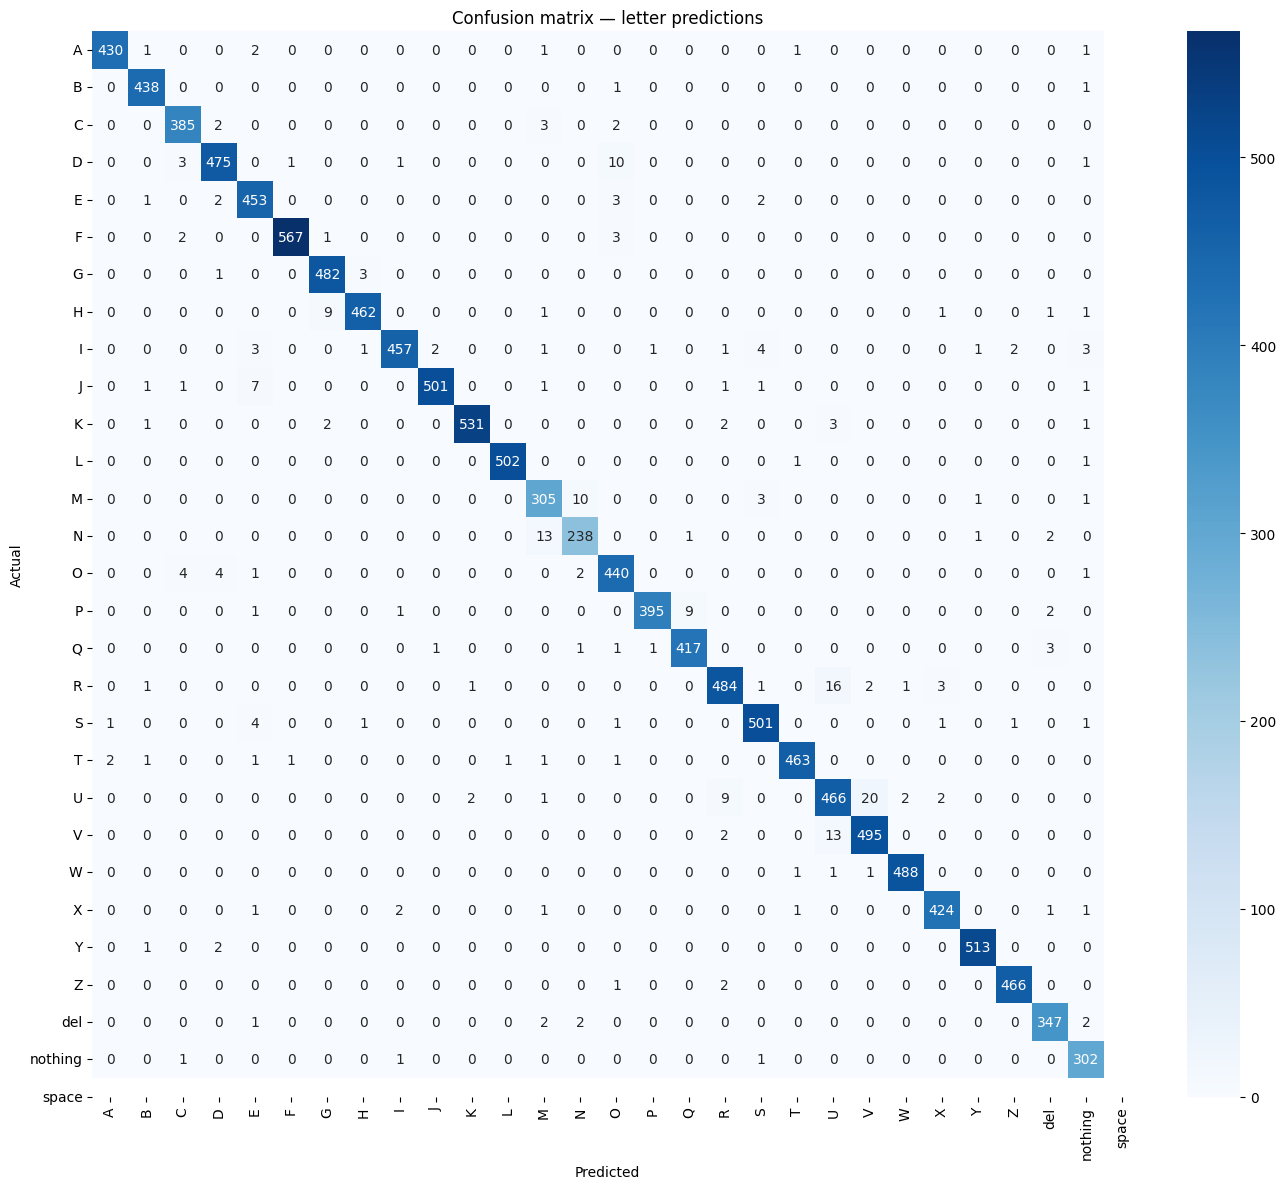

In [11]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(14, 12))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=le.classes_,
    yticklabels=le.classes_
)
plt.title('Confusion matrix — letter predictions')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

## Step 7 — Feature importance

Random Forest can tell us which of the 63 landmark values matter most for making predictions.

This is useful for two reasons:
1. It tells us which finger joints carry the most information about which letter is being signed
2. If the most important features look wrong (e.g. z-depth dominating), it hints at a data issue

We expect fingertip positions (landmarks 4, 8, 12, 16, 20) to rank highly since finger
positions are what distinguish most letters.

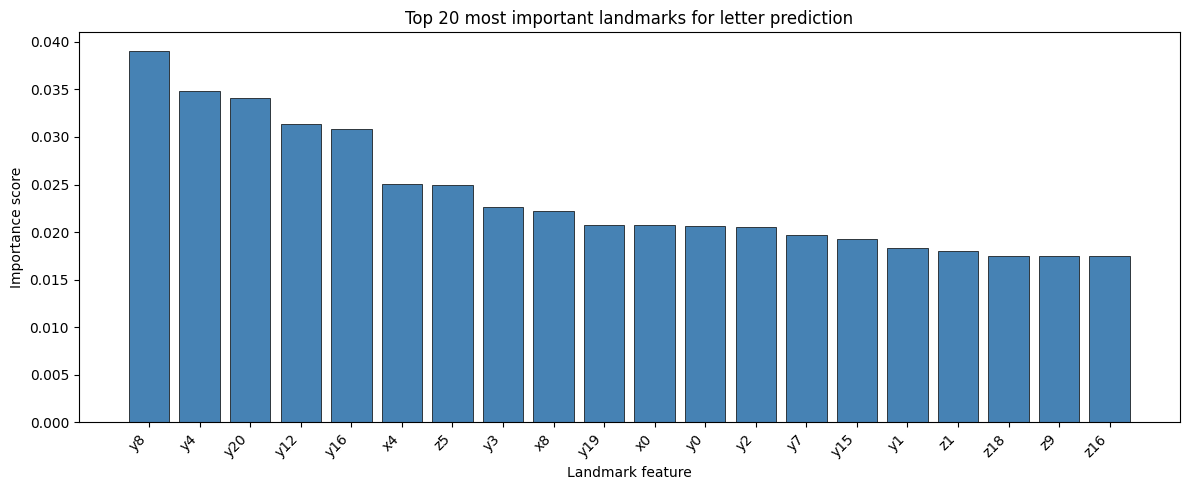

In [12]:
importances = model.feature_importances_
feature_names = df.drop('label', axis=1).columns

# Top 20 most important features
indices = np.argsort(importances)[::-1][:20]

plt.figure(figsize=(12, 5))
plt.bar(range(20), importances[indices], color='steelblue', edgecolor='black', linewidth=0.5)
plt.xticks(range(20), feature_names[indices], rotation=45, ha='right')
plt.title('Top 20 most important landmarks for letter prediction')
plt.xlabel('Landmark feature')
plt.ylabel('Importance score')
plt.tight_layout()
plt.show()

## Step 8 — Save the model

We save two things:
- `letter_model.pkl` — the trained Random Forest
- `label_encoder.pkl` — the label encoder that maps numbers back to letters

Both are needed at inference time. The model predicts a number, the encoder
turns that number back into a letter like "A" or "B".

In [13]:
os.makedirs('../models', exist_ok=True)

# Save model
with open('../models/letter_model.pkl', 'wb') as f:
    pickle.dump(model, f)

# Save label encoder
with open('../models/label_encoder.pkl', 'wb') as f:
    pickle.dump(le, f)

print("✅ Saved: models/letter_model.pkl")
print("✅ Saved: models/label_encoder.pkl")

✅ Saved: models/letter_model.pkl
✅ Saved: models/label_encoder.pkl


## Step 9 — Quick prediction test

Before closing the notebook, let's manually test the model on a few rows
from the test set to confirm it's working as expected end to end.

In [14]:
# Pick 10 random samples from the test set
sample_indices = np.random.choice(len(X_test), 10, replace=False)

print(f"{'True':>6}  {'Predicted':>10}  {'Confidence':>12}  {'Correct':>8}")
print("-" * 45)

for idx in sample_indices:
    true_label      = le.inverse_transform([y_test[idx]])[0]
    proba           = model.predict_proba([X_test[idx]])[0]
    pred_idx        = np.argmax(proba)
    pred_label      = le.inverse_transform([pred_idx])[0]
    confidence      = proba[pred_idx]
    correct         = "✅" if true_label == pred_label else "❌"

    print(f"{true_label:>6}  {pred_label:>10}  {confidence:>11.1%}  {correct:>8}")

  True   Predicted    Confidence   Correct
---------------------------------------------
     W           W        91.0%         ✅
     X           X        70.0%         ✅
     X           X        68.0%         ✅
     A           A        92.0%         ✅
     N           N        39.0%         ✅
     T           T        93.0%         ✅
     G           G        46.0%         ✅
     O           O        56.0%         ✅
     H           H        86.0%         ✅
     F           F        95.0%         ✅


## ✅ Notebook complete

**What we built:**
- Loaded the landmarks CSV (63 numbers per image)
- Trained a Random Forest on 80% of the data
- Evaluated accuracy on the 20% held-out test set
- Plotted the confusion matrix to see which letters get confused
- Saved the model and label encoder to `models/`

**What's next:**
Now we test it for real. Open `src/run.py` — that's the live camera script.
It loads the saved model, opens your camera, extracts landmarks from each frame,
and shows the predicted letter on screen in real time.

That's your first working demo.